# 10. Temporal Robustness Check

This notebook evaluates whether the strongest tabular model, XGBoost, can generalize across time. The main experiments used a stratified random train-validation-test split. However, since the Elliptic dataset includes time-step information, a temporal split is useful as a robustness check.

In this setup, earlier time steps are used for training, middle time steps are used for validation, and later time steps are used for testing. This better reflects a realistic fraud detection setting where models are trained on historical transactions and evaluated on future transactions.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    precision_recall_curve
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 1000)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## 10.1 Load Labeled Elliptic Dataset

The cleaned labeled dataset created during preprocessing is loaded. This dataset contains only licit and illicit labeled transactions and includes the time-step variable required for temporal splitting.

In [2]:
PROJECT_DIR = Path.cwd().resolve()

if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
RESULTS_DIR = PROJECT_DIR / "results"
FIGURES_DIR = PROJECT_DIR / "figures"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

data_path = PROCESSED_DIR / "elliptic_labeled_transactions.csv"

df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("Columns:", df.columns[:10].tolist())
print("\nLabel distribution:")
print(df["label"].value_counts())
print("\nTime-step range:")
print(df["time_step"].min(), "to", df["time_step"].max())
print("\nNumber of unique time steps:", df["time_step"].nunique())

display(df.iloc[:5, :12])

Dataset shape: (46564, 169)
Columns: ['txId', 'time_step', '2', '3', '4', '5', '6', '7', '8', '9']

Label distribution:
label
0    42019
1     4545
Name: count, dtype: int64

Time-step range:
1 to 49

Number of unique time steps: 49


,txId,time_step,2,3,4,5,6,7,8,9,10,11
0,232438397,1,0.163054,1.963790,-0.646376,12.409294,-0.063725,9.782742,12.414558,-0.163645,-0.115831,0.043598
1,232029206,1,-0.005027,0.578941,-0.091383,4.380281,-0.063725,4.667146,0.851305,-0.163645,-0.144554,0.020069
2,232344069,1,-0.147852,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.137933,-0.144108,-0.049707
3,27553029,1,-0.151357,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.141519,-0.147643,-0.049707
4,3881097,1,-0.172306,-0.184668,-1.201369,0.028105,-0.043875,-0.029140,0.242712,-0.163640,-0.169115,-0.047227


## 10.2 Create Temporal Train, Validation, and Test Split

The time steps are sorted chronologically. The first 60% of time steps are used for training, the next 20% for validation, and the final 20% for testing.

In [3]:
unique_steps = sorted(df["time_step"].unique())

n_steps = len(unique_steps)
train_end = int(0.60 * n_steps)
val_end = int(0.80 * n_steps)

train_steps = unique_steps[:train_end]
val_steps = unique_steps[train_end:val_end]
test_steps = unique_steps[val_end:]

train_df = df[df["time_step"].isin(train_steps)].copy()
val_df = df[df["time_step"].isin(val_steps)].copy()
test_df = df[df["time_step"].isin(test_steps)].copy()

print("Number of time steps:", n_steps)
print("Train time steps:", min(train_steps), "to", max(train_steps), "| count:", len(train_steps))
print("Validation time steps:", min(val_steps), "to", max(val_steps), "| count:", len(val_steps))
print("Test time steps:", min(test_steps), "to", max(test_steps), "| count:", len(test_steps))

print("\nTrain shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain label distribution:")
print(train_df["label"].value_counts(normalize=False))
print(train_df["label"].value_counts(normalize=True).round(4))

print("\nValidation label distribution:")
print(val_df["label"].value_counts(normalize=False))
print(val_df["label"].value_counts(normalize=True).round(4))

print("\nTest label distribution:")
print(test_df["label"].value_counts(normalize=False))
print(test_df["label"].value_counts(normalize=True).round(4))

Number of time steps: 49
Train time steps: 1 to 29 | count: 29
Validation time steps: 30 to 39 | count: 10
Test time steps: 40 to 49 | count: 10

Train shape: (26381, 169)
Validation shape: (8999, 169)
Test shape: (11184, 169)

Train label distribution:
label
0    23510
1     2871
Name: count, dtype: int64
label
0    0.8912
1    0.1088
Name: proportion, dtype: float64

Validation label distribution:
label
0    7961
1    1038
Name: count, dtype: int64
label
0    0.8847
1    0.1153
Name: proportion, dtype: float64

Test label distribution:
label
0    10548
1      636
Name: count, dtype: int64
label
0    0.9431
1    0.0569
Name: proportion, dtype: float64


## 10.3 Visualize Temporal Split

The following plot shows how the labeled transactions are divided across training, validation, and test periods.

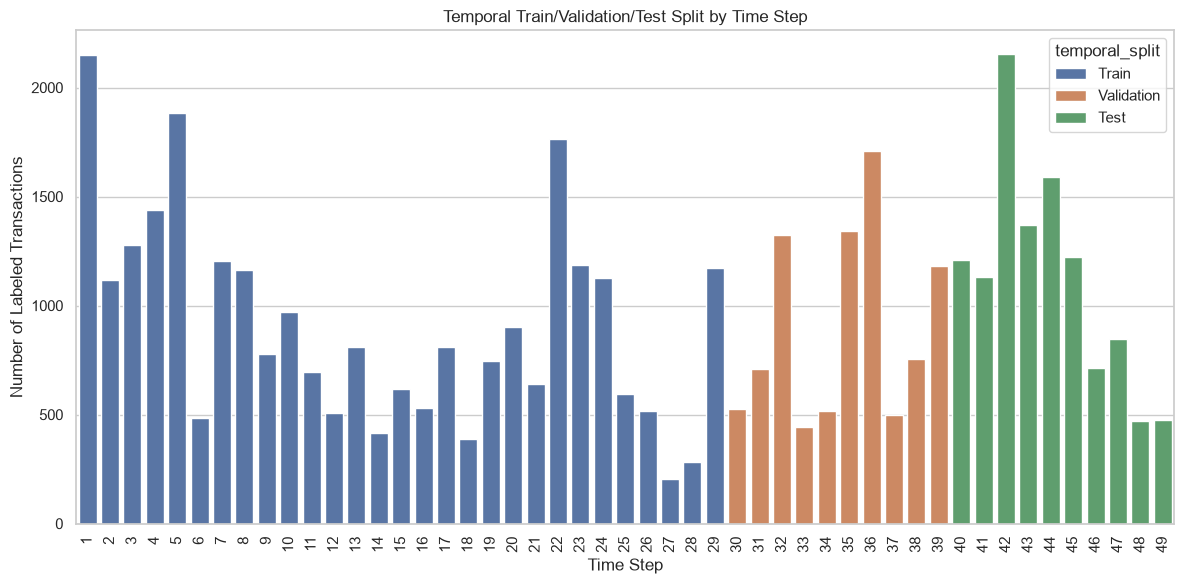

In [4]:
df = df.copy()
df["temporal_split"] = "Unused"

df.loc[df["time_step"].isin(train_steps), "temporal_split"] = "Train"
df.loc[df["time_step"].isin(val_steps), "temporal_split"] = "Validation"
df.loc[df["time_step"].isin(test_steps), "temporal_split"] = "Test"

split_time_counts = df.groupby(["time_step", "temporal_split"]).size().reset_index(name="count")

plt.figure(figsize=(12, 6))
sns.barplot(data=split_time_counts, x="time_step", y="count", hue="temporal_split")
plt.title("Temporal Train/Validation/Test Split by Time Step")
plt.xlabel("Time Step")
plt.ylabel("Number of Labeled Transactions")
plt.xticks(rotation=90)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "temporal_split_by_time_step.png", dpi=300)
plt.show()

## 10.4 Prepare Features and Labels

Transaction ID, time step, original class label, and binary target label are excluded from the feature matrix. The same anonymized feature columns used in earlier tabular models are used here.

In [5]:
exclude_cols = ["txId", "time_step", "class", "label"]

feature_cols = [col for col in df.columns if col not in exclude_cols and col != "temporal_split"]

X_train = train_df[feature_cols]
y_train = train_df["label"]

X_val = val_df[feature_cols]
y_val = val_df["label"]

X_test = test_df[feature_cols]
y_test = test_df["label"]

print("Number of features:", len(feature_cols))
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

Number of features: 165
X_train: (26381, 165)
X_val: (8999, 165)
X_test: (11184, 165)


## 10.5 Train XGBoost on Temporal Split

XGBoost is trained using the temporal training set. Class imbalance is handled using `scale_pos_weight`, calculated from the temporal training labels.

In [6]:
num_negative = (y_train == 0).sum()
num_positive = (y_train == 1).sum()

scale_pos_weight = num_negative / num_positive

print("Temporal train licit:", num_negative)
print("Temporal train illicit:", num_positive)
print("scale_pos_weight:", round(scale_pos_weight, 4))

temporal_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

temporal_xgb.fit(X_train, y_train)

print("Temporal XGBoost training completed.")

Temporal train licit: 23510
Temporal train illicit: 2871
scale_pos_weight: 8.1888
Temporal XGBoost training completed.


## 10.6 Evaluate Temporal XGBoost

The model is first evaluated using the default classification threshold. Performance is then compared with the main random-split XGBoost result.

In [7]:
def evaluate_binary_model(y_true, y_pred, y_proba):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba)
    }

In [8]:
val_proba = temporal_xgb.predict_proba(X_val)[:, 1]
test_proba = temporal_xgb.predict_proba(X_test)[:, 1]

val_pred = (val_proba >= 0.5).astype(int)
test_pred = (test_proba >= 0.5).astype(int)

temporal_val_metrics = evaluate_binary_model(y_val, val_pred, val_proba)
temporal_test_metrics = evaluate_binary_model(y_test, test_pred, test_proba)

print("Temporal XGBoost Validation Metrics:")
for k, v in temporal_val_metrics.items():
    print(f"{k}: {v:.4f}")

print("\nTemporal XGBoost Test Metrics:")
for k, v in temporal_test_metrics.items():
    print(f"{k}: {v:.4f}")

print("\nTemporal XGBoost Test Classification Report:")
print(classification_report(y_test, test_pred, digits=4))

temporal_test_cm = confusion_matrix(y_test, test_pred)
print("\nTemporal XGBoost Test Confusion Matrix:")
print(temporal_test_cm)

Temporal XGBoost Validation Metrics:
accuracy: 0.9828
precision: 0.9122
recall: 0.9412
f1: 0.9265
roc_auc: 0.9924
pr_auc: 0.9709

Temporal XGBoost Test Metrics:
accuracy: 0.9601
precision: 0.6644
recall: 0.6038
f1: 0.6326
roc_auc: 0.8735
pr_auc: 0.6640

Temporal XGBoost Test Classification Report:
              precision    recall  f1-score   support

           0     0.9762    0.9816    0.9789     10548
           1     0.6644    0.6038    0.6326       636

    accuracy                         0.9601     11184
   macro avg     0.8203    0.7927    0.8058     11184
weighted avg     0.9585    0.9601    0.9592     11184


Temporal XGBoost Test Confusion Matrix:
[[10354   194]
 [  252   384]]


## 10.7 Threshold Tuning for Temporal XGBoost

A validation-based threshold is selected to maximize F1-score. This is applied to the temporal test set.

In [9]:
precisions, recalls, thresholds = precision_recall_curve(y_val, val_proba)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best temporal validation threshold based on F1:", round(best_threshold, 4))
print("Validation precision at best threshold:", round(precisions[best_idx], 4))
print("Validation recall at best threshold:", round(recalls[best_idx], 4))
print("Validation F1 at best threshold:", round(f1_scores[best_idx], 4))

Best temporal validation threshold based on F1: 0.5906
Validation precision at best threshold: 0.9413
Validation recall at best threshold: 0.9268
Validation F1 at best threshold: 0.934


In [10]:
test_pred_tuned = (test_proba >= best_threshold).astype(int)

temporal_test_metrics_tuned = evaluate_binary_model(y_test, test_pred_tuned, test_proba)
temporal_test_cm_tuned = confusion_matrix(y_test, test_pred_tuned)

print("Temporal XGBoost Tuned-Threshold Test Metrics:")
for k, v in temporal_test_metrics_tuned.items():
    print(f"{k}: {v:.4f}")

print("\nTemporal XGBoost Tuned-Threshold Test Classification Report:")
print(classification_report(y_test, test_pred_tuned, digits=4))

print("\nTemporal XGBoost Tuned Confusion Matrix:")
print(temporal_test_cm_tuned)

Temporal XGBoost Tuned-Threshold Test Metrics:
accuracy: 0.9643
precision: 0.7257
recall: 0.5991
f1: 0.6563
roc_auc: 0.8735
pr_auc: 0.6640

Temporal XGBoost Tuned-Threshold Test Classification Report:
              precision    recall  f1-score   support

           0     0.9761    0.9863    0.9812     10548
           1     0.7257    0.5991    0.6563       636

    accuracy                         0.9643     11184
   macro avg     0.8509    0.7927    0.8188     11184
weighted avg     0.9618    0.9643    0.9627     11184


Temporal XGBoost Tuned Confusion Matrix:
[[10404   144]
 [  255   381]]


## 10.8 Compare Random Split and Temporal Split

The temporal split result is compared with the main random-split XGBoost result. The random-split result remains the primary controlled benchmark, while the temporal split is treated as a robustness check.

In [11]:
temporal_comparison_df = pd.DataFrame([
    {
        "experiment": "Random split XGBoost",
        "threshold_type": "Default",
        "accuracy": 0.9918,
        "precision": 0.9749,
        "recall": 0.9406,
        "f1": 0.9574,
        "roc_auc": 0.9974,
        "pr_auc": 0.9860
    },
    {
        "experiment": "Temporal split XGBoost",
        "threshold_type": "Default",
        "accuracy": temporal_test_metrics["accuracy"],
        "precision": temporal_test_metrics["precision"],
        "recall": temporal_test_metrics["recall"],
        "f1": temporal_test_metrics["f1"],
        "roc_auc": temporal_test_metrics["roc_auc"],
        "pr_auc": temporal_test_metrics["pr_auc"]
    },
    {
        "experiment": "Temporal split XGBoost",
        "threshold_type": "Tuned",
        "accuracy": temporal_test_metrics_tuned["accuracy"],
        "precision": temporal_test_metrics_tuned["precision"],
        "recall": temporal_test_metrics_tuned["recall"],
        "f1": temporal_test_metrics_tuned["f1"],
        "roc_auc": temporal_test_metrics_tuned["roc_auc"],
        "pr_auc": temporal_test_metrics_tuned["pr_auc"]
    }
])

display(temporal_comparison_df)

temporal_comparison_df.to_csv(
    RESULTS_DIR / "temporal_xgboost_robustness_comparison.csv",
    index=False
)

,experiment,threshold_type,accuracy,precision,recall,f1,roc_auc,pr_auc
0,Random split XGBoost,Default,0.991800,0.974900,0.940600,0.957400,0.997400,0.986000
1,Temporal split XGBoost,Default,0.960122,0.664360,0.603774,0.632619,0.873491,0.663986
2,Temporal split XGBoost,Tuned,0.964324,0.725714,0.599057,0.656331,0.873491,0.663986


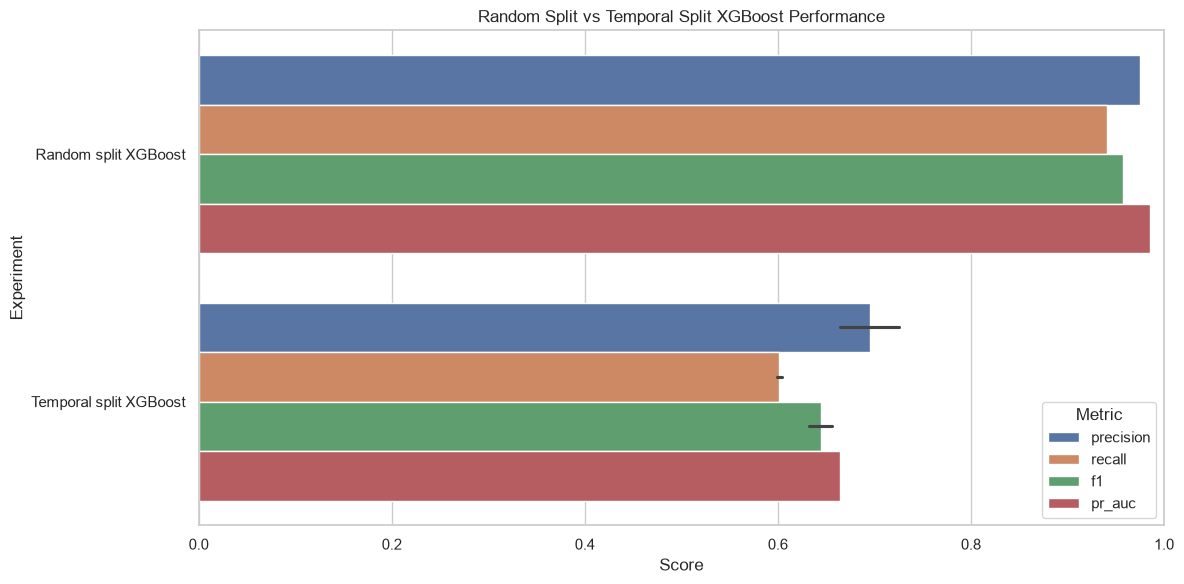

In [12]:
temporal_plot_df = temporal_comparison_df.melt(
    id_vars=["experiment", "threshold_type"],
    value_vars=["precision", "recall", "f1", "pr_auc"],
    var_name="metric",
    value_name="score"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=temporal_plot_df, x="score", y="experiment", hue="metric")
plt.title("Random Split vs Temporal Split XGBoost Performance")
plt.xlabel("Score")
plt.ylabel("Experiment")
plt.xlim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "random_vs_temporal_xgboost_comparison.png", dpi=300)
plt.show()

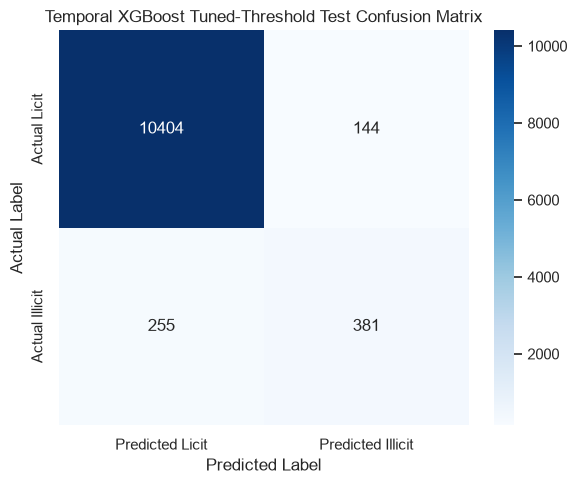

In [13]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    temporal_test_cm_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Licit", "Predicted Illicit"],
    yticklabels=["Actual Licit", "Actual Illicit"]
)
plt.title("Temporal XGBoost Tuned-Threshold Test Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "temporal_xgboost_tuned_confusion_matrix.png", dpi=300)
plt.show()

## 10.9 Temporal Robustness Interpretation

The temporal split provides a more realistic evaluation because the model is trained on earlier transactions and tested on later transactions. If performance decreases compared with the random split, this indicates that temporal generalization is more difficult than random classification. This does not invalidate the main results, instead, it strengthens the analysis by showing how the model behaves under a more realistic deployment-oriented setting.